In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import matplotlib.patches as mpatches

In [3]:
CSF_AD = pd.read_csv('data/CSF_AD.csv')
dx_df = pd.read_csv('data/DXSUM_17Feb2026.csv')

In [4]:
def pretty_label(var_name):
    """
    Converts snake_case variable names into publication-ready labels.
    """

    # Remove common prefixes
    prefixes = ["adas_", "cdr_", "mmse_"]
    for p in prefixes:
        if var_name.startswith(p):
            var_name = var_name[len(p):]

    # Replace underscores with spaces
    var_name = var_name.replace("_", " ")

    # Capitalize words
    var_name = var_name.title()

    return f"{var_name} Score (ADAS-Cog)" 


In [5]:
def quadratic_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
    {variable} ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c+ Sleep + Z867 
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_years:PT_AB_std
    + time_years:age_c
    + time_years:PTGENDER
    + time_years:edu_c
    + time_sq:CARRIER
    + time_sq:edu_c
    + time_sq:age_c
    + time_sq:PT_AB_std
    + time_years:Sleep
    + time_years:Z867
    + time_sq:Sleep
    + time_sq:Z867
    """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.05]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"quadratic_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )

    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 3, "Low"),
        (0.5, "-",  3, "Median"),
        (0.9, "--", 3, "High")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)
       
        if q == 0.5:
            ref_color = "#1b9e77"
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )

    fig.savefig(
        f"quadratic_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic




In [6]:

def linear_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
        {variable} ~ time_years
        + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + Z867 
        + time_years:baseline_c 
        + time_years:HOMO
        + time_years:CARRIER 
        + time_years:PT_AB_std 
        + time_years:age_c 
        + time_years:PTGENDER 
        + time_years:edu_c 
        + time_years:Sleep
        + time_years:Z867
       
        """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.05]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"linear_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )

    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 3, "Low (P10)"),
        (0.5, "-",  3, "Median"),
        (0.9, "--", 3, "High (P90)")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)

       
        if q == 0.5:
            ref_color = "#1b9e77"  
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )

    fig.savefig(
        f"linear_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def compare_lin_quad(variable, data):
    bic_linear = linear_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"linear_{variable}"
    )
    bic_quadratic = quadratic_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"quadratic_{variable}"
    )
    print(f"BIC Linear: {bic_linear}")
    print(f"BIC Quadratic: {bic_quadratic}")

In [7]:
def compare_lin_quad(variable, data):
    bic_linear = linear_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"linear_{variable}"
    )
    bic_quadratic = quadratic_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"quadratic_{variable}"
    )
    print(f"BIC Linear: {bic_linear}")
    print(f"BIC Quadratic: {bic_quadratic}")

### Compare how many individuals start and end as CN, MCI, AD:

=== First Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     339
MCI    495
AD     186
Name: count, dtype: int64
  Missing: 0

=== Last Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     277
MCI    341
AD     402
Name: count, dtype: int64
  Missing: 0

=== Transition counts (first → last) ===
last_dx      AD     CN    MCI
first_dx                     
AD        185.0    0.0    1.0
CN         24.0  259.0   56.0
MCI       193.0   18.0  284.0


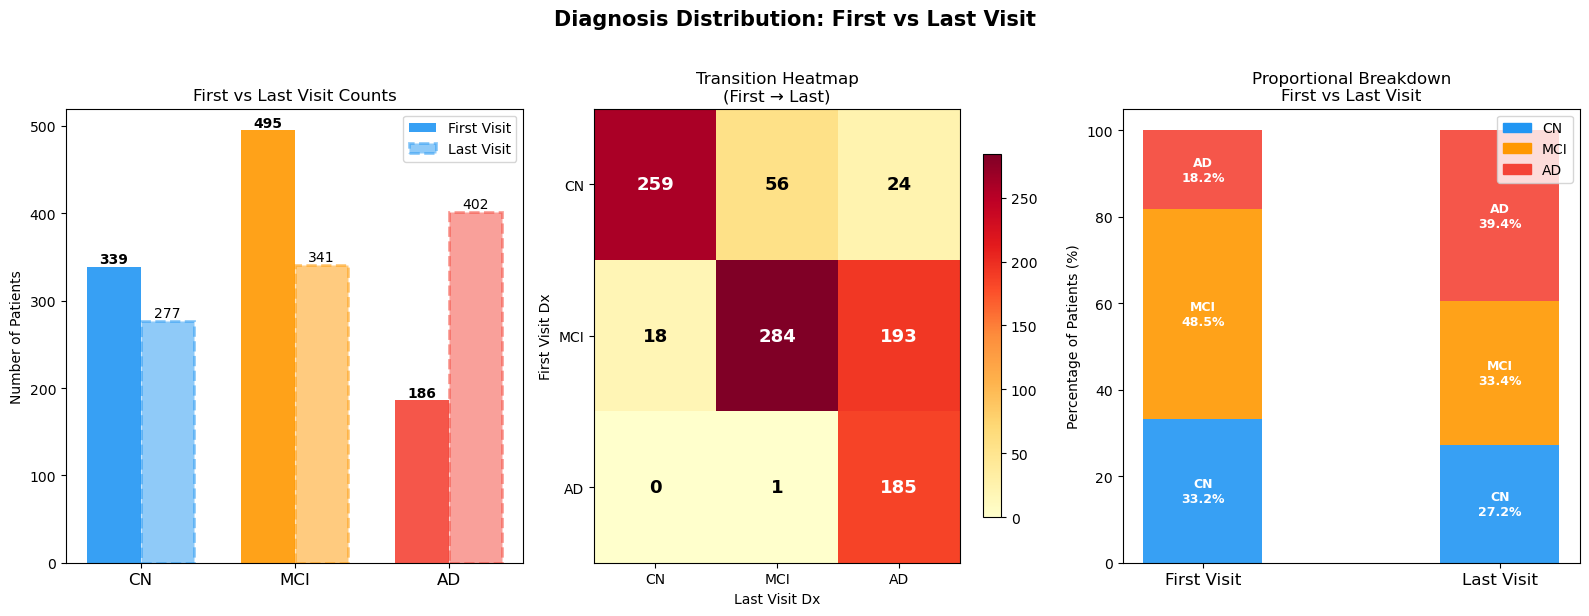

Plot saved.


In [12]:
# ── 1. Merge on RID + VISCODE ──────────────────────────────────────────────
merged = CSF_AD.merge(
    dx_df[['RID', 'VISCODE', 'DIAGNOSIS']],
    on=['RID', 'VISCODE'],
    how='left'
)

diag_map = {1: 'CN', 2: 'MCI', 3: 'AD'}
merged['DIAGNOSIS_LABEL'] = merged['DIAGNOSIS'].map(diag_map)

# ── 2. First & last visit per patient (by days_since_baseline}) ───────────────────
merged_sorted = merged.sort_values(['RID', 'days_since_entry'])

first_visit = merged_sorted.groupby('RID').first().reset_index()
last_visit  = merged_sorted.groupby('RID').last().reset_index()

first_counts = first_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)
last_counts  = last_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)

print("=== First Visit Diagnosis ===")
print(first_counts)
print(f"  Missing: {first_visit['DIAGNOSIS_LABEL'].isna().sum()}")

print("\n=== Last Visit Diagnosis ===")
print(last_counts)
print(f"  Missing: {last_visit['DIAGNOSIS_LABEL'].isna().sum()}")

# ── 3. Sankey-style transition counts ─────────────────────────────────────
transitions = merged_sorted.groupby('RID').agg(
    first_dx=('DIAGNOSIS_LABEL', 'first'),
    last_dx=('DIAGNOSIS_LABEL', 'last')
).reset_index()

transition_counts = transitions.groupby(['first_dx', 'last_dx']).size().reset_index(name='count')
print("\n=== Transition counts (first → last) ===")
print(transition_counts.pivot(index='first_dx', columns='last_dx', values='count').fillna(0))

# ── 4. Plot ────────────────────────────────────────────────────────────────
colors = {'CN': '#2196F3', 'MCI': '#FF9800', 'AD': '#F44336'}
categories = ['CN', 'MCI', 'AD']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Diagnosis Distribution: First vs Last Visit', fontsize=15, fontweight='bold', y=1.02)

# — Panel 1: Grouped bar chart —
ax1 = axes[0]
x = np.arange(len(categories))
w = 0.35
bars1 = ax1.bar(x - w/2, [first_counts[c] for c in categories], w,
                label='First Visit', color=[colors[c] for c in categories], alpha=0.9)
bars2 = ax1.bar(x + w/2, [last_counts[c] for c in categories],  w,
                label='Last Visit',  color=[colors[c] for c in categories], alpha=0.5,
                edgecolor=[colors[c] for c in categories], linewidth=2, linestyle='--')
ax1.set_xticks(x); ax1.set_xticklabels(categories, fontsize=12)
ax1.set_ylabel('Number of Patients'); ax1.set_title('First vs Last Visit Counts')
ax1.legend()
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# — Panel 2: Transition heatmap —
ax2 = axes[1]
pivot = transitions.groupby(['first_dx', 'last_dx']).size().unstack(fill_value=0).reindex(
    index=categories, columns=categories, fill_value=0)
im = ax2.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(len(categories))); ax2.set_xticklabels(categories)
ax2.set_yticks(range(len(categories))); ax2.set_yticklabels(categories)
ax2.set_xlabel('Last Visit Dx'); ax2.set_ylabel('First Visit Dx')
ax2.set_title('Transition Heatmap\n(First → Last)')
for i in range(len(categories)):
    for j in range(len(categories)):
        val = pivot.values[i, j]
        ax2.text(j, i, str(int(val)), ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if val > pivot.values.max()*0.6 else 'black')
plt.colorbar(im, ax=ax2, shrink=0.8)

# — Panel 3: Stacked % bar —
ax3 = axes[2]
total_first = first_counts.sum()
total_last  = last_counts.sum()
bottom_f = bottom_l = 0
for cat in categories:
    pf = first_counts[cat] / total_first * 100
    pl = last_counts[cat]  / total_last  * 100
    ax3.bar(0, pf, bottom=bottom_f, color=colors[cat], alpha=0.9, width=0.4)
    ax3.bar(1, pl, bottom=bottom_l, color=colors[cat], alpha=0.9, width=0.4)
    if pf > 3: ax3.text(0, bottom_f + pf/2, f'{cat}\n{pf:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if pl > 3: ax3.text(1, bottom_l + pl/2, f'{cat}\n{pl:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom_f += pf; bottom_l += pl
ax3.set_xticks([0, 1]); ax3.set_xticklabels(['First Visit', 'Last Visit'], fontsize=12)
ax3.set_ylabel('Percentage of Patients (%)'); ax3.set_title('Proportional Breakdown\nFirst vs Last Visit')
patches = [mpatches.Patch(color=colors[c], label=c) for c in categories]
ax3.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.savefig('diagnosis_first_last.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [13]:
# ── Group 1: All patients ──────────────────────────────────────────────────
df_all = CSF_AD.merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 1 - All patients:          n = {df_all['RID'].nunique()} patients, {len(df_all)} rows")

# ── Group 2: End up as MCI or AD at last visit ─────────────────────────────
progressors_rid = transitions[transitions['last_dx'].isin(['MCI', 'AD'])]['RID']
df_progressors = CSF_AD[CSF_AD['RID'].isin(progressors_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 2 - End MCI or AD:         n = {df_progressors['RID'].nunique()} patients, {len(df_progressors)} rows")

# ── Group 3: End up as AD at last visit ────────────────────────────────────
ad_converters_rid = transitions[transitions['last_dx'] == 'AD']['RID']
df_ad_converters = CSF_AD[CSF_AD['RID'].isin(ad_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 3 - End AD:                n = {df_ad_converters['RID'].nunique()} patients, {len(df_ad_converters)} rows")

# ── Group 4: AD at entry (first visit already AD) ─────────────────────────
ad_at_entry_rid = transitions[transitions['first_dx'] == 'AD']['RID']
df_ad_entry = CSF_AD[CSF_AD['RID'].isin(ad_at_entry_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 4 - AD at entry:           n = {df_ad_entry['RID'].nunique()} patients, {len(df_ad_entry)} rows")

# ── Summary table ──────────────────────────────────────────────────────────
print("\n=== First → Last diagnosis breakdown per group ===")
for name, df in [("All", df_all), ("End MCI/AD", df_progressors),
                 ("End AD", df_ad_converters), ("AD at entry", df_ad_entry)]:
    print(f"\n{name}:")
    print(df.drop_duplicates('RID')[['first_dx', 'last_dx']]
            .groupby(['first_dx', 'last_dx']).size().reset_index(name='n').to_string(index=False))

Group 1 - All patients:          n = 1020 patients, 16783 rows
Group 2 - End MCI or AD:         n = 743 patients, 12304 rows
Group 3 - End AD:                n = 402 patients, 5895 rows
Group 4 - AD at entry:           n = 186 patients, 635 rows

=== First → Last diagnosis breakdown per group ===

All:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1
      CN      AD  24
      CN      CN 259
      CN     MCI  56
     MCI      AD 193
     MCI      CN  18
     MCI     MCI 284

End MCI/AD:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1
      CN      AD  24
      CN     MCI  56
     MCI      AD 193
     MCI     MCI 284

End AD:
first_dx last_dx   n
      AD      AD 185
      CN      AD  24
     MCI      AD 193

AD at entry:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1


In [ ]:
print(compare_lin_quad("TOTAL13", df_all))
print(compare_lin_quad("TOTAL13", df_progressors))
print(compare_lin_quad("TOTAL13", df_ad_converters))


Significant predictors for TOTAL13:
                            coef          pval
Intercept              12.006485  0.000000e+00
time_years              1.443226  7.347786e-34
age_c                   0.064198  5.461462e-05
edu_c                  -0.047712  3.776929e-02
baseline_c              0.975150  0.000000e+00
time_years:baseline_c   0.101856  5.780308e-20
time_years:PT_AB_std    1.027344  2.901982e-22
RID Var                 0.466089  2.001705e-52
RID x time_years Cov    0.110691  6.795473e-09
time_years Var          0.398142  6.275358e-41

Saved files:
 → linear_TOTAL13_TOTAL13_trajectories.png
 → linear_TOTAL13_TOTAL13_significant_results.csv

Significant predictors for TOTAL13:
                              coef           pval
Intercept                12.674012   0.000000e+00
time_years                0.686074   2.106732e-07
time_sq                   0.143080  9.868605e-282
time_sq:CARRIER[T.True]   0.015688   6.253323e-04
age_c                     0.046175   1.926725e-03
ba

In [14]:
for df, name in [(CSF_AD, "All patients"), (df_progressors, "Progressors"), (df_ad_converters, "AD converters")]:
    print(f"\n=== {name} (n={df['RID'].nunique()}) ===")
    for condition in ["UTI", "Dental", "Z864", "Z867", "Sleep"]:
        n = df[df[condition] == 1]["RID"].nunique()
        print(f"  {condition}: {n} patients ({100*n/df['RID'].nunique():.1f}%)")


=== All patients (n=1020) ===
  UTI: 41 patients (4.0%)
  Dental: 1 patients (0.1%)
  Z864: 19 patients (1.9%)
  Z867: 70 patients (6.9%)
  Sleep: 199 patients (19.5%)

=== Progressors (n=743) ===
  UTI: 32 patients (4.3%)
  Dental: 1 patients (0.1%)
  Z864: 15 patients (2.0%)
  Z867: 57 patients (7.7%)
  Sleep: 158 patients (21.3%)

=== AD converters (n=402) ===
  UTI: 18 patients (4.5%)
  Dental: 1 patients (0.2%)
  Z864: 11 patients (2.7%)
  Z867: 32 patients (8.0%)
  Sleep: 79 patients (19.7%)
